In [13]:
import xarray as xr
import pandas as pd
import pysteps

In [22]:
def load_radolan_netcdf(filename, rain_variable_name="rainfall_amount", **kwargs):
    """Load data on RADOLAN grid"""

    ds = xr.open_dataset(filename)

    data = ds[rain_variable_name].data
    timestamps = pd.to_datetime(ds.time.values).to_pydatetime()
    timestep = (timestamps[1] - timestamps[0]).total_seconds() / 60

    if 'x' not in ds.dims:
        xpixelsize = abs(ds.longitudes[1].values - ds.longitudes[0].values)
    else:
        xpixelsize = abs(ds.longitudes.diff(dim="x").isel(x=0, y=0).item())

    if 'y' not in ds.dims:
        ypixelsize = abs(ds.latitudes[1].values - ds.latitudes[0].values)
    else:
        ypixelsize = ds.latitudes.diff(dim="y").isel(x=0, y=0).item()

    metadata = {
        'accutime': 60,
         'institution': 'DWD',
         'product': 'AQC',
        #  The data is a lon-lat grid, so the projection is EPSG:4326
         'projection': 'EPSG:4326',
         'cartesian_unit': 'degree',
         'threshold': 0,
         'timestamps': timestamps,
         'transform': None,
         'unit': 'mm',
         'x1': ds.longitudes.min().item(),
         'x2': ds.longitudes.max().item(),
         'xpixelsize': xpixelsize,
         'y1': ds.latitudes.min().item(),
         'y2': ds.latitudes.max().item(),
         'yorigin': 'lower',
         'ypixelsize': ypixelsize,
         'zerovalue': 0,
         'zr_a': 316.0,
         'zr_b': 1.5,
    }

    return data, metadata, timestep

data, metadata, timestep = load_radolan_netcdf('/Users/chwala-c/RW_gauge.nc', rain_variable_name='RW')


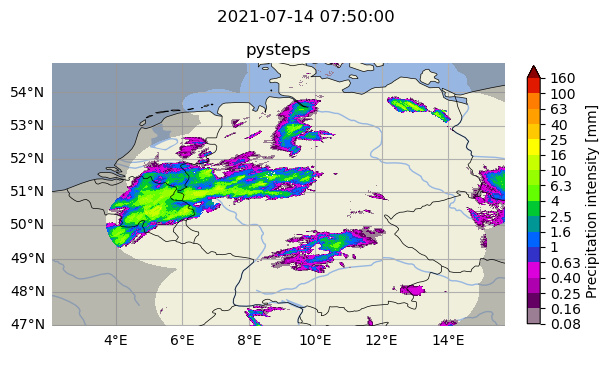

In [30]:
from pysteps.visualization import plot_precip_field
from matplotlib import pyplot as plt

# Disable warnings
import warnings
warnings.filterwarnings("ignore")

plot_index = 25

fig = plt.figure(figsize=(6, 10), layout="constrained")
# set the title to the timestamp of the last precipitation field
plt.suptitle(metadata["timestamps"][plot_index])

map_kwargs = {"drawlonlatlines": True}

# plot the last precipitation field
# turn off axis, because it will be overwritten in plot_precip_field
ax = fig.add_subplot(311); ax.axis("off")
plot_precip_field(
    data[plot_index],
    geodata=metadata,
    title="pysteps",
    colorscale="pysteps",
    map_kwargs=map_kwargs,
    units="mm",
);

In [31]:
from pysteps import motion
from pysteps.utils import transformation
from pysteps.visualization import plot_precip_field, quiver

In [71]:
oflow = motion.get_method('LK')

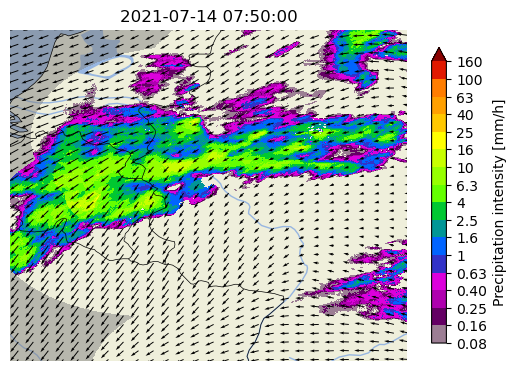

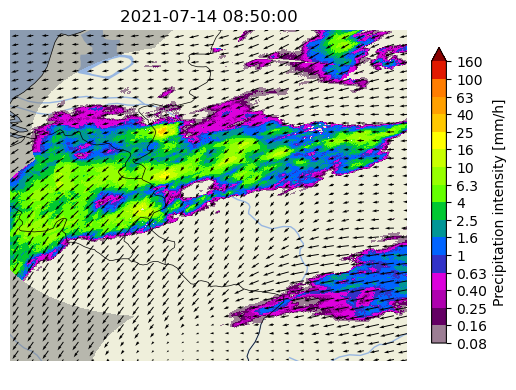

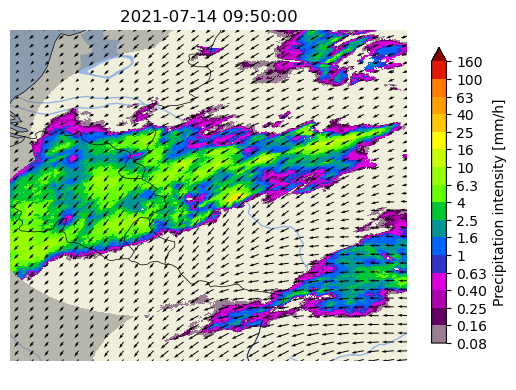

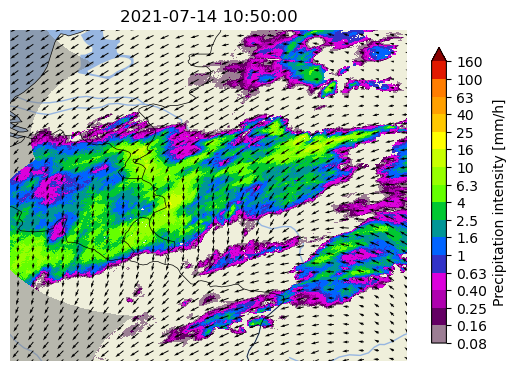

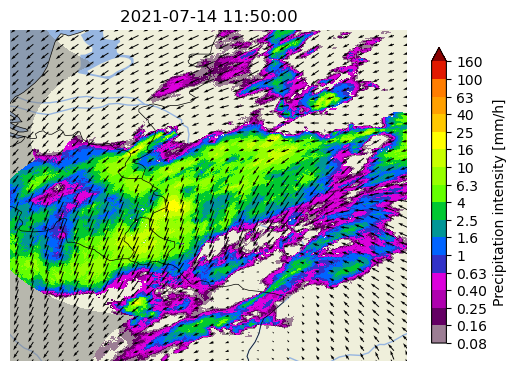

In [74]:
for i in range(25, 30):
    data_dbr, metadata_dbr = transformation.dB_transform(data, metadata=metadata, threshold=0.1, zerovalue=-15)
    advection = oflow(data_dbr[i-2:i], verbose=False)
    fig, ax = plt.subplots()
    ax.axis("off")
    bbox = (4, 48, 10, 53)
    quiver(advection, geodata=metadata, step=15, quiver_kwargs={"scale": 1000})
    plot_precip_field(data[i], geodata=metadata, bbox=bbox, title=metadata['timestamps'][i])
    plt.show()
